# [1교시]

core point : 반지름안에 있는 점들 \
core point >= min_samples(최소기준) \
core -> core -> core : 자연스럽게 군집을 형성한다.

밀도가 높은 곳은 계속 연결되어 있다. -> 하나의 큰 덩어리인 클러스터 \
반지름 안에 있는 점들을 찾는 문제는 주어진 중심점과 지름을 기준으로, 해당 반지름 안에 위치한 점들을 찾는 문제.

이 문제는 주로 2차원 평면에서 다루어지며, 중심점과 반지름이 주어졌을 때, 해당 반지름 안에 있는 점들의 좌표를 반호나하는 방식으로 해결된다.
- 이 문제를 해결하기 위해서는 다음과 같은 단계를 거친다.

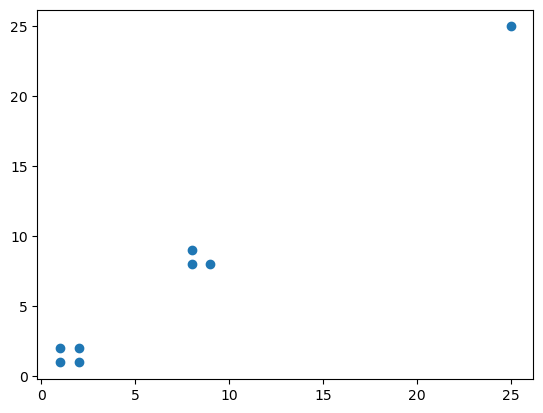

In [1]:
# 샘플데이터
import numpy as np
import matplotlib.pyplot as plt
X = np.array(
    [[1,1], [1,2], [2,1], [2,2], [8,8], [8,9], [9, 8], [25,25]]
)
X.shape
plt.scatter(X[:,0], X[:,1])
plt.show()

In [2]:
import numpy as np
# 반지름 1.5안에 3개 이상 있으면 core point
esp = 1.5
min_samples=3

# 현재 점 p0(1, 1)
round(np.sqrt((2-1)**2 + (2-1)**2),1)

# 이웃 4
# p0(1,1) p1(1,2), p2(2,1), p3(2,2)
# 주변찾기 p1 -> p2 -> p3

np.float64(1.4)

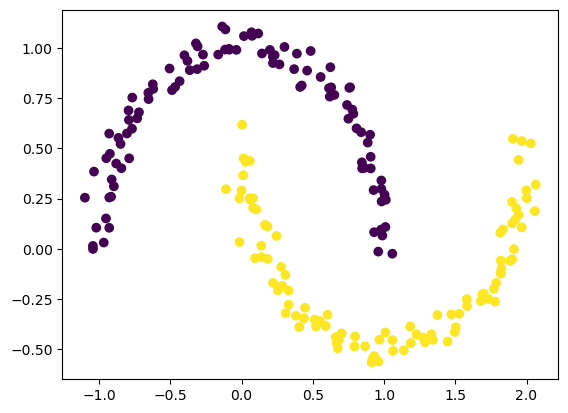

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
np.random.seed(42)
X, y = make_moons(
    n_samples=200,
    noise = 0.05, random_state=42
    # centers=[(-2, 2), (2, 2), (5, -3)],
    # cluster_std=[0.8, 0.7, 0.6]
)
# # 노이즈 추가
# noise = np.random.uniform(low=-6, high=6, size=(20,2))
# X = np.vstack([X, noise])

plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

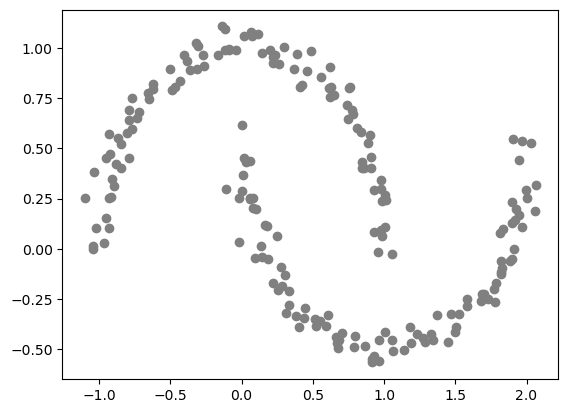

In [4]:
# step 1 초기화(모든점 미방문)
UNVISITED = -1
NOISE = -2
n = len(X)
labels = np.full(n, UNVISITED)

esp = 0.3
min_samples = 5
cluster_id = 0
plt.scatter(X[:,0], X[:,1],c='gray')
plt.show()

# [2교시]

In [5]:
# step 2 : 반경내 이웃찾기
def region_query(X, point_idx, esp):
    '''
    X : 전체데이터셋
    point_idx : 기준점 Core point후보 인덱스
    eps : 이웃으로인정하기위한 최대거리 즉 반경(Epsilon)
    '''
    distance = np.linalg.norm(    
        X - X[point_idx],
        axis=1  # 열단위로 연산
    )
    neighbors = np.where(distance <= esp)[0]    
    return neighbors

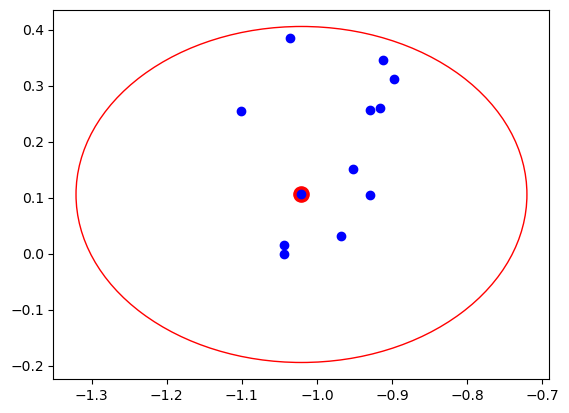

In [6]:
# step 3 Core point 확인
point_index = 0
neighbors = region_query(X, point_index, esp)
# 현재 점
plt.scatter(
    X[point_index, 0], X[point_index, 1],
    c='red', s=120
)

# 이웃 점
plt.scatter(
    X[neighbors, 0], X[neighbors, 1],
    c='blue'
)

# esp 원
circle = plt.Circle(
    X[point_index], esp, color='red', fill=False
)
plt.gca().add_patch(circle)
plt.show()

In [7]:
import numpy as np
# 반지름 1.5안에 3개이상 있으면 core point
esp=1.5
min_samples=3
# 현재점 p0(1,1)
round(np.sqrt((2-1)**2 + (2-1)**2),1)
# 이웃 4
# p0(1,1) p1(1,2) p2(2,1) p3(2,2)
# 주변찾기 p1->p2->p3

np.float64(1.4)

12
18
21
21
19
19
20
20
19
20


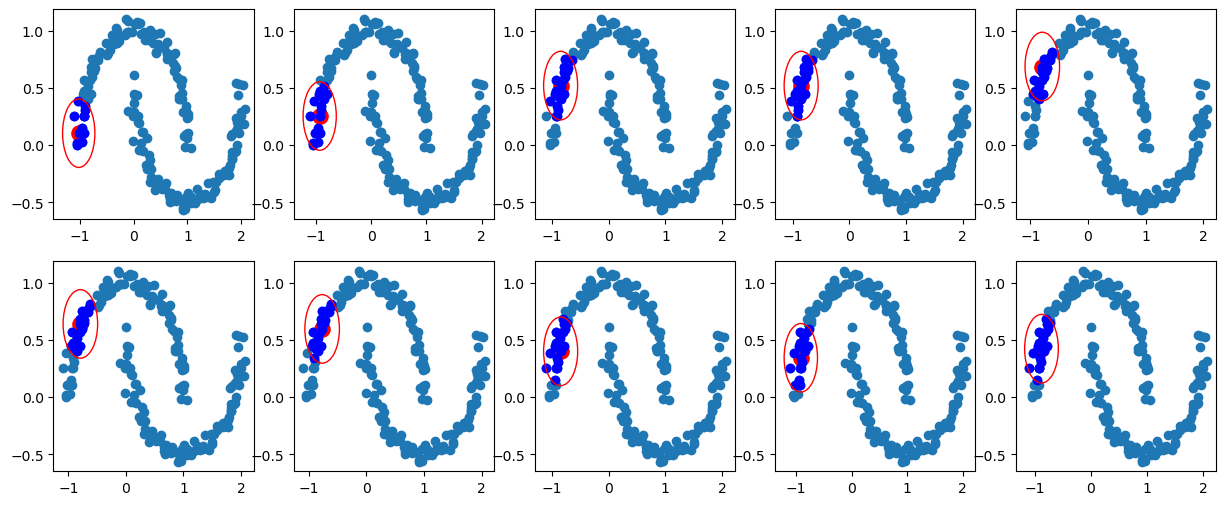

In [8]:
# step3 Core Pont 확인
neighbors = region_query(X, 0, esp)
esp = 0.3
fig, ax = plt.subplots(2,5,figsize=(15,6))
for i in range(10):
    point_index = neighbors[i]

    neighbors = region_query(X, point_index, esp)
    # 전체점
    ax[i//5, i%5].scatter(X[:,0], X[:,1])

    # 현재 점
    ax[i//5, i%5].scatter(
        X[point_index,0], X[point_index,1],
        c='red',s=120
    )
    # 이웃점
    ax[i//5, i%5].scatter(
        X[neighbors,0], X[neighbors,1],
        c='blue'
    )
    print(len(X[neighbors]))

    # esp 원
    circle = plt.Circle(
        X[point_index], esp, color='red',fill=False
    )
    ax[i//5, i%5].add_patch(circle)
plt.show()

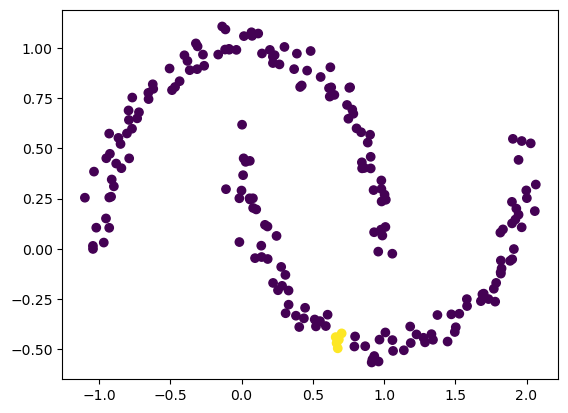

In [9]:
# 라이브러리 이용
from sklearn.cluster import DBSCAN
model = DBSCAN(eps=0.05, min_samples=5)
sk_labels = model.fit_predict(X)
plt.scatter(
    X[:,0], X[:,1], c=sk_labels
)
plt.show()

# [3교시]

In [10]:
# 계층적 군집화
# 처음에는 모든 점이 혼자 있음
# 가장 가까운 두 점 찾기
# 그 둘을 하나의 그룹으로 묶기
# 다시 가장 가까운 그룹 찾기
# 반복
# 결국 하나의 큰 그룹이 됨

# 섬들이 점점 다리로 연결되는 과정

# Dendrogram : 군집화를 거꾸로 그린것

왼쪽 그룹 오른쪽 그룹

P0 ●   ● P1

                     P2 ●
                             ● P3

              가운데 멀리

                            ● P4
                            ● P5

p0 p1 p2 p3 p4 p5
ㅣ  ㅣ ㅣ ㅣ ㅣ ㅣ 
 ---   ---  ---

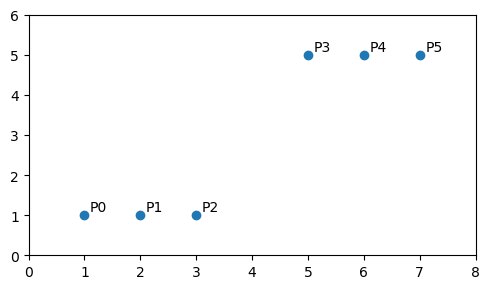

In [11]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5,3))
# 사슬모양
X = np.array([
    [1,1],[2,1],[3,1],[5,5],[6,5],[7,5]
])
plt.scatter(X[:,0], X[:,1])
for i, (x,y) in enumerate(X):
    plt.text(x+0.1,y+0.1,f'P{i}')
plt.ylim(0,6)    
plt.xlim(0,8)
plt.tight_layout()    

In [12]:
# 군집간 거리
# linkage Criterion
# single Linkage (가장 가까운 점 기준)
# complete Linkage (가장 먼 점 기준)
# average Linkage (모든 점 거리 평균)

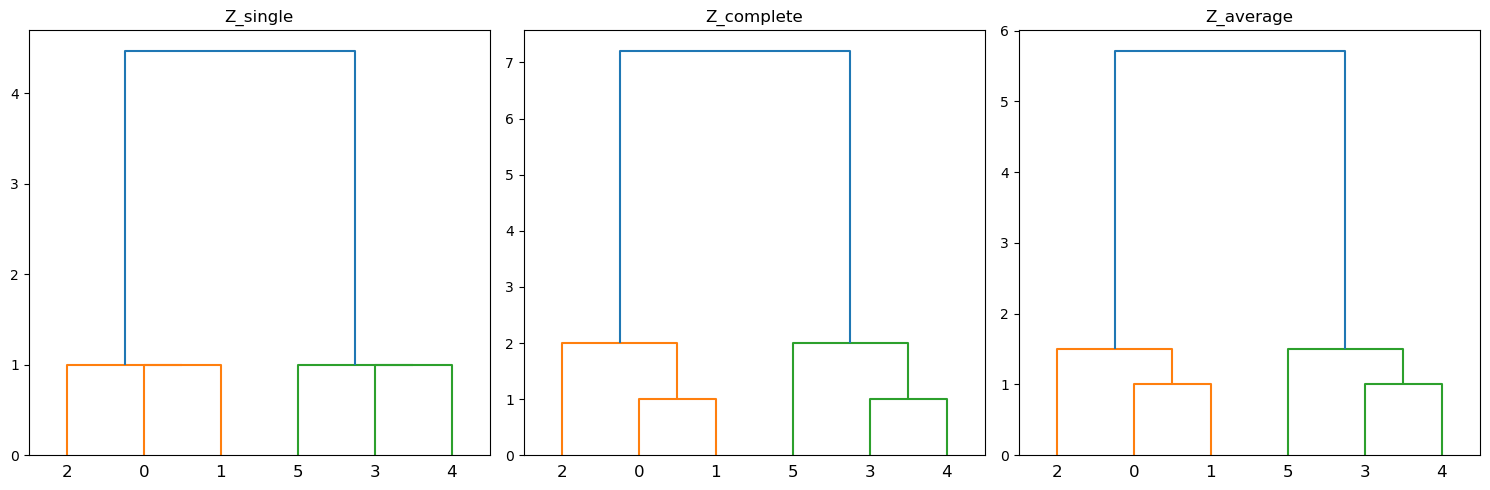

In [13]:
from scipy.cluster.hierarchy import linkage
Z_single = linkage(X, method='single')
Z_complete = linkage(X, method='complete')
Z_average = linkage(X, method='average')

from scipy.cluster.hierarchy import dendrogram
fig,ax = plt.subplots(1,3,figsize=(15,5))
dendrogram(Z_single, ax = ax[0])
dendrogram(Z_complete, ax = ax[1])
dendrogram(Z_average, ax = ax[2])
ax[0].set_title('Z_single');ax[1].set_title('Z_complete');ax[2].set_title('Z_average')
plt.tight_layout()
plt.show()

In [14]:
# single : 연결만 되면 같은 군집 즉 군집이 계속 이어지는 모양
# complete : 군집이 더 단단해 짐 , 퍼지는걸 막음, 더 조밀함
# Average  : 균형잡힌 결과

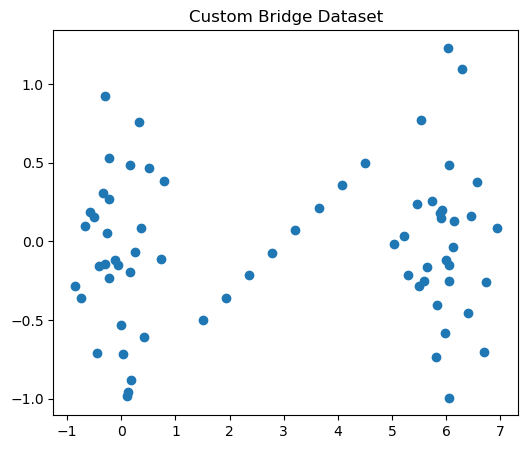

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

np.random.seed(42)

# 왼쪽 cluster
X1, _ = make_blobs(
    n_samples=30,
    centers=[[0,0]],
    cluster_std=0.5
)

# 오른쪽 cluster
X2, _ = make_blobs(
    n_samples=30,
    centers=[[6,0]],
    cluster_std=0.5
)

# 대각선 bridge 생성 (핵심)
bridge_x = np.linspace(1.5, 4.5, 8)
bridge_y = np.linspace(-0.5, 0.5, 8)

bridge = np.column_stack([
    bridge_x,
    bridge_y
])

# 전체 데이터 합치기
X = np.vstack([X1, X2, bridge])

# 데이터 시각화
plt.figure(figsize=(6,5))

plt.scatter(X[:,0], X[:,1])

plt.title("Custom Bridge Dataset")

plt.show()

In [16]:
# 사이킷런
from sklearn.cluster import AgglomerativeClustering
n_clusters = 2
# single linkage
model_single = AgglomerativeClustering(n_clusters=n_clusters, linkage='single')
model_complete = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')
model_average = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')

label_single = model_single.fit_predict(X)
label_complete = model_complete.fit_predict(X)
label_average = model_average.fit_predict(X)

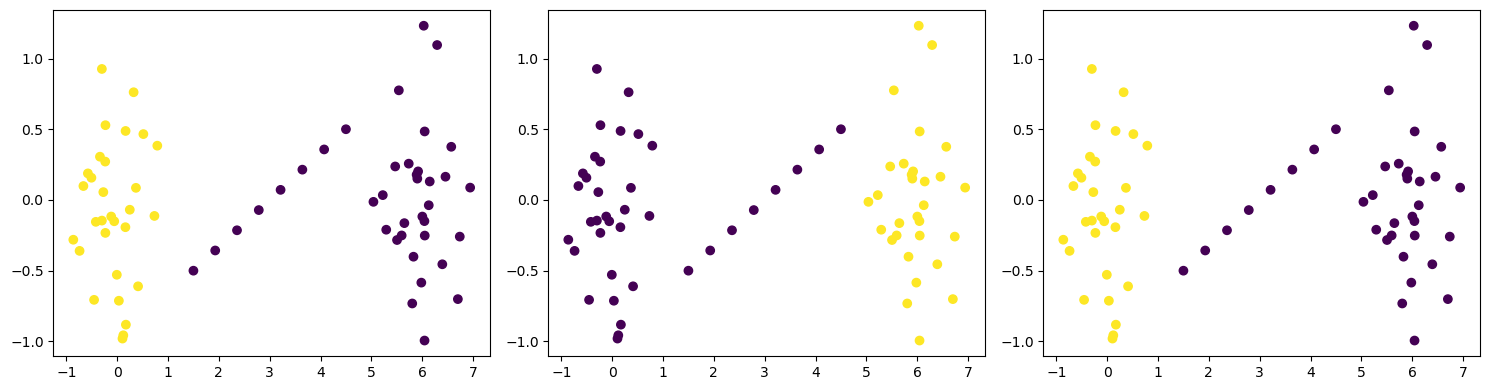

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(X[:,0], X[:,1], c=label_single)
ax[1].scatter(X[:,0], X[:,1], c=label_complete)
ax[2].scatter(X[:,0], X[:,1], c=label_average)
plt.tight_layout()
plt.show()

# [4교시]

In [18]:
# 군집
# kmeans, DBSCAN, 게층적군집(싱글, 컴플리트, 평균)

from sklearn.datasets import fetch_olivetti_faces
olivetti = fetch_olivetti_faces()
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [19]:
print(X.shape)
olivetti.target

(68, 2)


array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

In [20]:
X = olivetti.data
y = olivetti.target

In [21]:
import numpy as np
np.sqrt(4096), X.shape

(np.float64(64.0), (400, 4096))

In [22]:
X[0].mean(), X[0].std()

(np.float32(0.6368469), np.float32(0.14939392))

In [23]:
round(X[0].min()), round(X[0].max())

(0, 1)

In [24]:
# 데이터 분할
from collections import Counter
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test \
    = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
Counter(y_test)

Counter({np.int64(36): 4,
         np.int64(26): 4,
         np.int64(13): 4,
         np.int64(10): 4,
         np.int64(34): 4,
         np.int64(28): 4,
         np.int64(7): 4,
         np.int64(14): 4,
         np.int64(39): 4,
         np.int64(12): 4,
         np.int64(0): 4,
         np.int64(37): 4,
         np.int64(32): 4,
         np.int64(35): 4,
         np.int64(20): 4,
         np.int64(21): 4,
         np.int64(5): 4,
         np.int64(29): 4,
         np.int64(19): 4,
         np.int64(23): 4,
         np.int64(11): 4,
         np.int64(8): 4,
         np.int64(6): 4,
         np.int64(30): 4,
         np.int64(33): 4,
         np.int64(18): 4,
         np.int64(25): 4,
         np.int64(16): 4,
         np.int64(2): 4,
         np.int64(3): 4,
         np.int64(31): 4,
         np.int64(4): 4,
         np.int64(38): 4,
         np.int64(15): 4,
         np.int64(27): 4,
         np.int64(1): 4,
         np.int64(22): 4,
         np.int64(24): 4,
         np.int64(17)

In [25]:
# 연산속도 높이기 (PCA)
from sklearn.decomposition import PCA
pca = PCA(n_components=0.99)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
pca.n_components_

np.int64(177)

# [5교시]

In [26]:
# kmeans로 군집 구분
# 최적의 k 개수
# DBSCAN
# 계층적 군집화

In [27]:
# k평균 군집화
# OMP_NUM_THREADS=1  환경셋팅
import os
os.environ["OMP_NUM_THREADS"] = '1'

c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a m

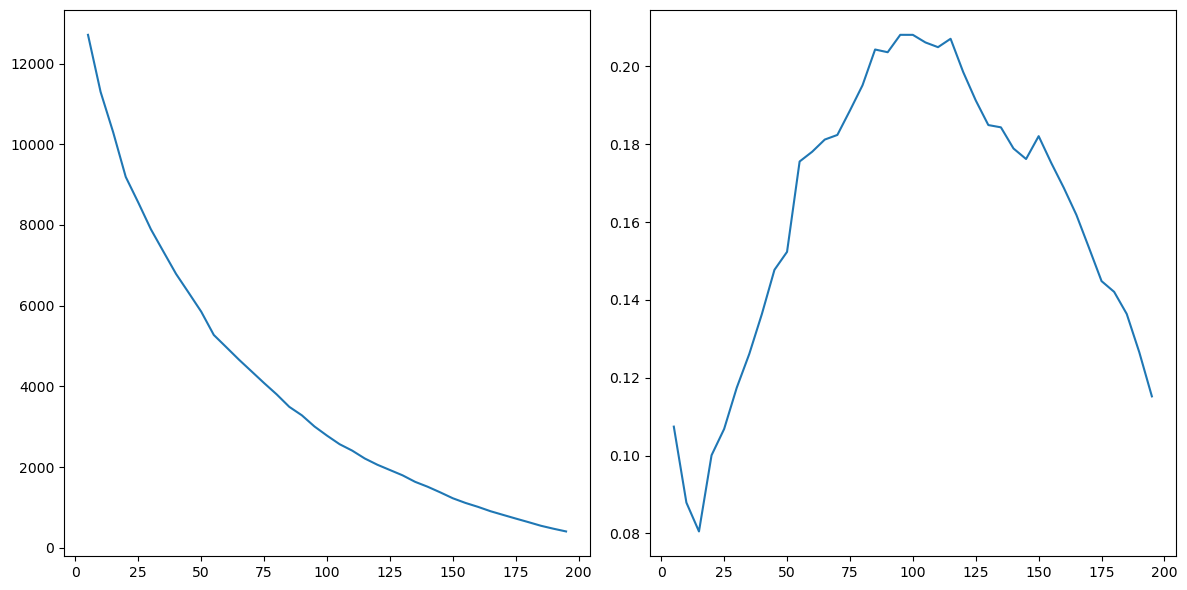

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
k_range = range(5,200,5)
ellow = []
sillhouet_scores = []
for k in k_range:
    km = KMeans(n_clusters=k,random_state=42)
    km.fit(X_train_pca)
    
    sillhouet_scores.append(silhouette_score(X_train_pca, km.labels_))
    ellow.append(km.inertia_)

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].plot(k_range,ellow )
ax[1].plot(k_range,sillhouet_scores)
plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

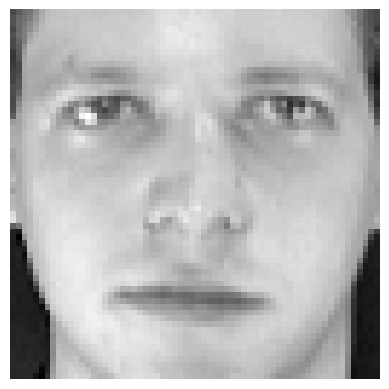

In [47]:
# 64 X 64
plt.imshow(X[0].reshape(64, 64), cmap='gray')
plt.axis('off')

# [6교시]

label = 0


c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


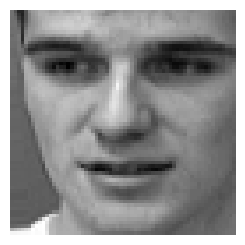

label = 1


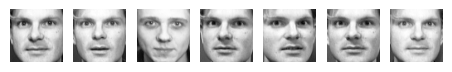

label = 2


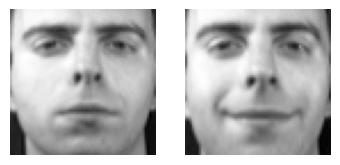

label = 3


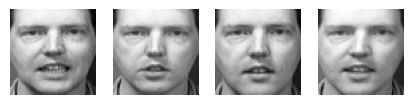

label = 4


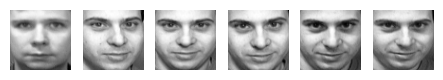

label = 5


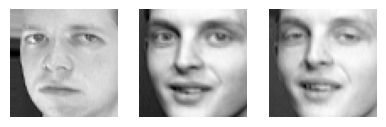

label = 6


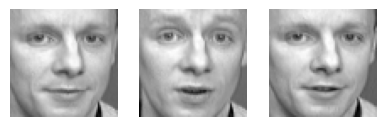

label = 7


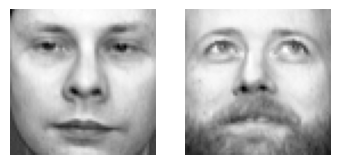

label = 8


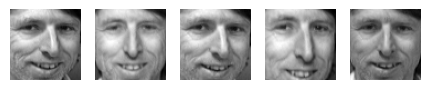

label = 9


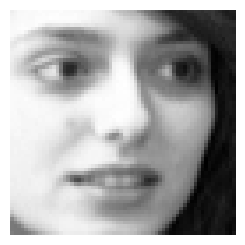

label = 10


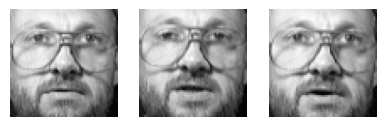

label = 11


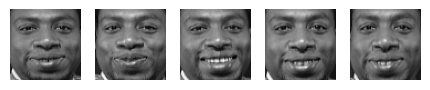

label = 12


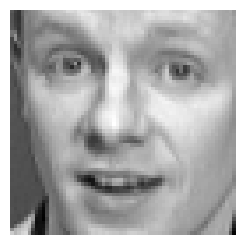

label = 13


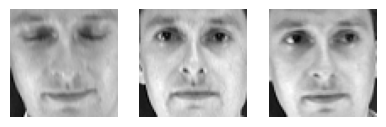

label = 14


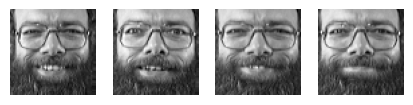

label = 15


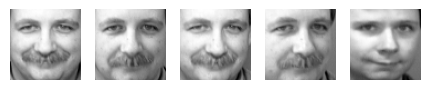

label = 16


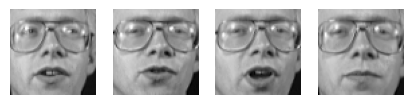

label = 17


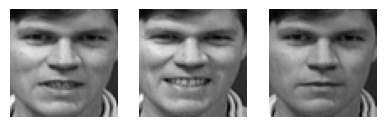

label = 18


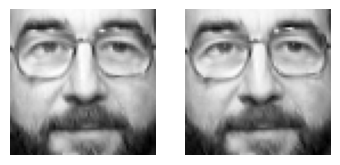

label = 19


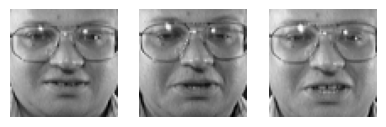

label = 20


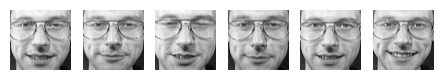

label = 21


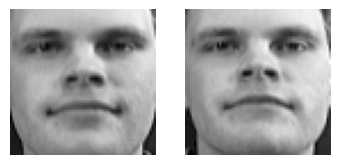

label = 22


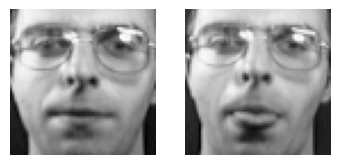

label = 23


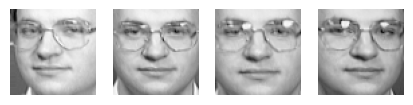

label = 24


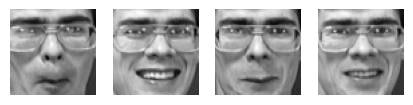

label = 25


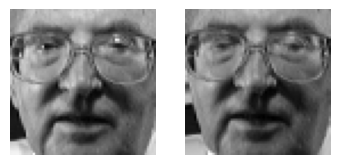

label = 26


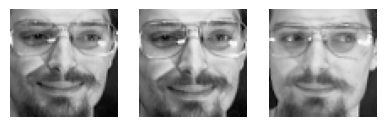

label = 27


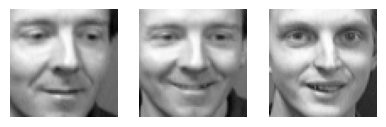

label = 28


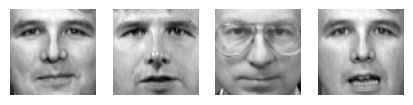

label = 29


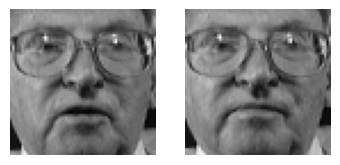

label = 30


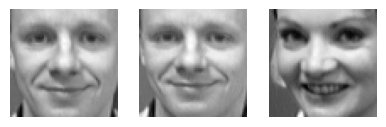

label = 31


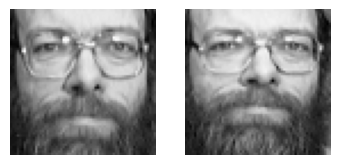

label = 32


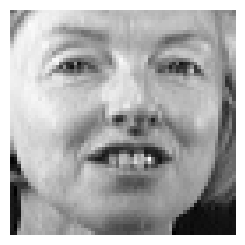

label = 33


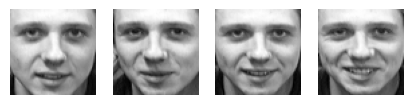

label = 34


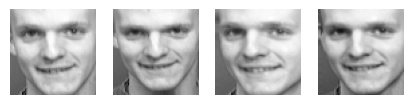

label = 35


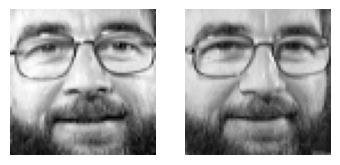

label = 36


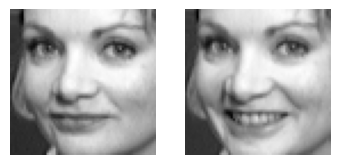

label = 37


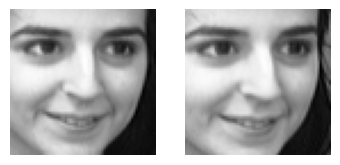

label = 38


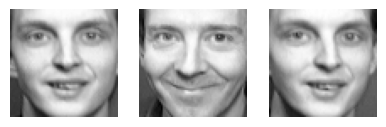

label = 39


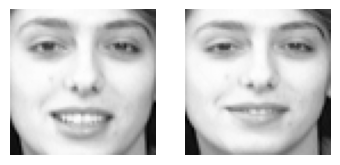

label = 40


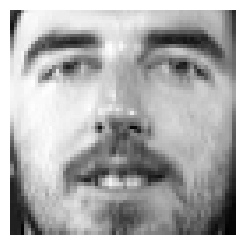

label = 41


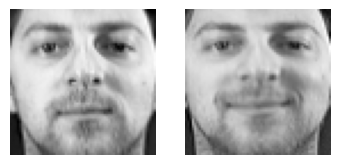

label = 42


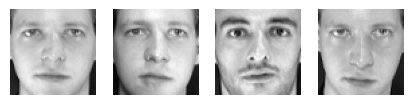

label = 43


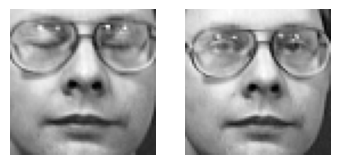

label = 44


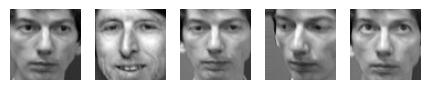

label = 45


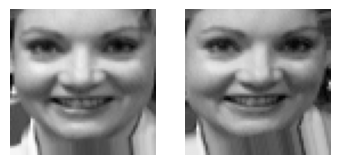

label = 46


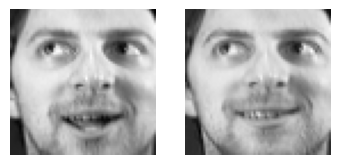

label = 47


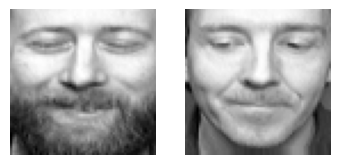

label = 48


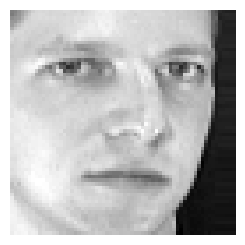

label = 49


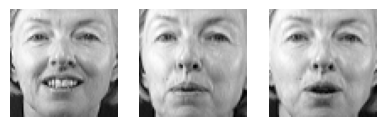

label = 50


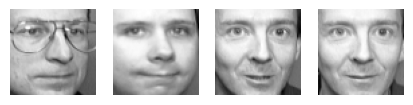

label = 51


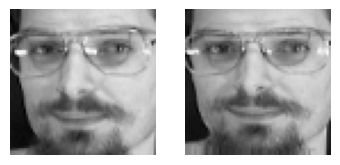

label = 52


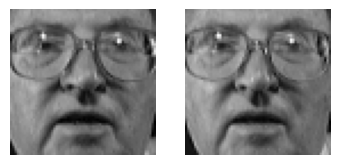

label = 53


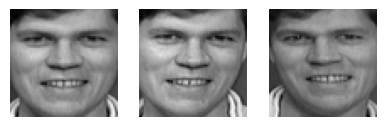

label = 54


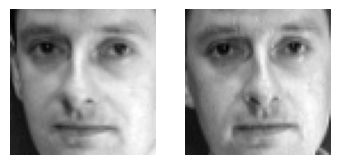

label = 55


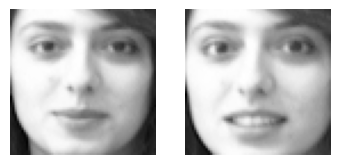

label = 56


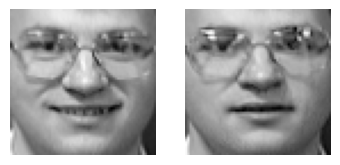

label = 57


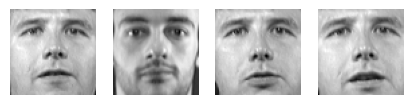

label = 58


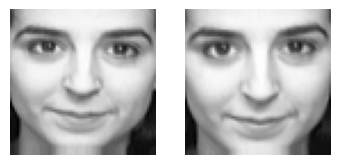

label = 59


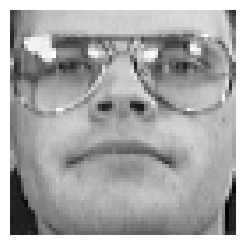

label = 60


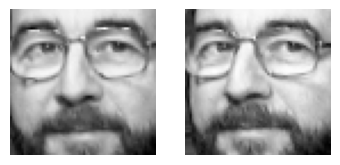

label = 61


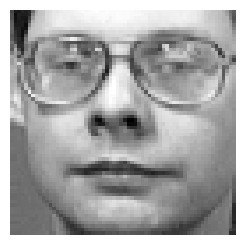

label = 62


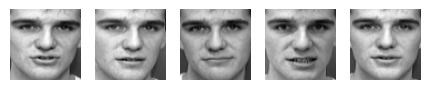

label = 63


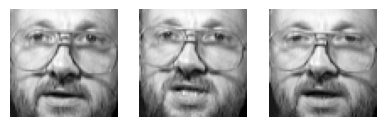

label = 64


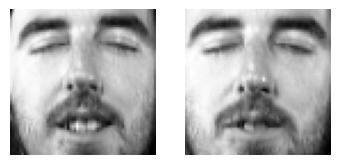

label = 65


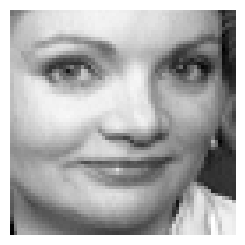

label = 66


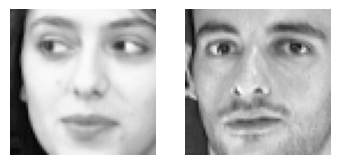

label = 67


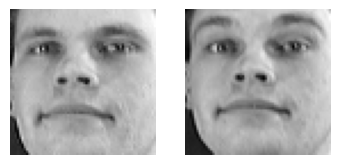

label = 68


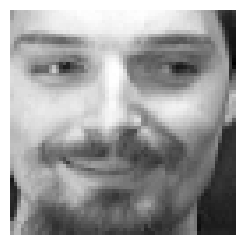

label = 69


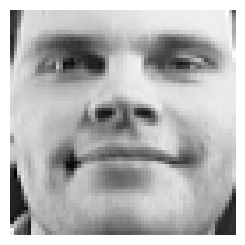

label = 70


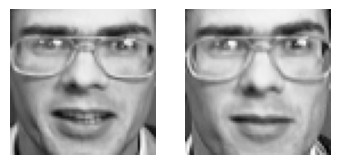

label = 71


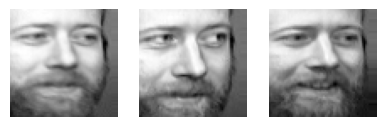

label = 72


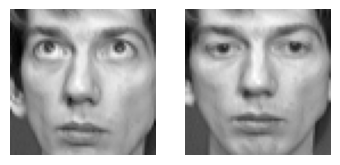

label = 73


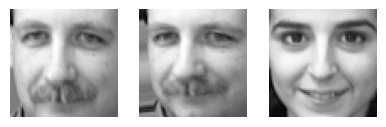

label = 74


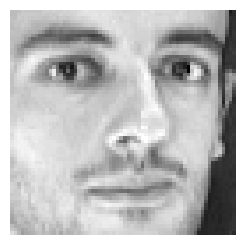

label = 75


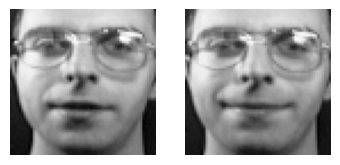

label = 76


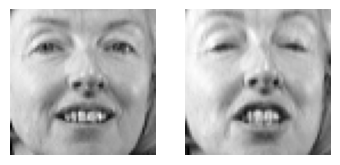

label = 77


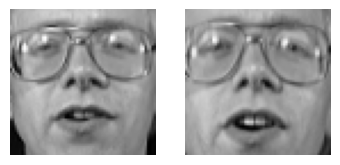

label = 78


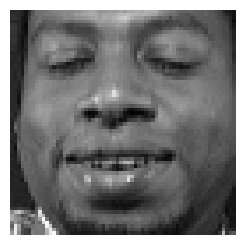

label = 79


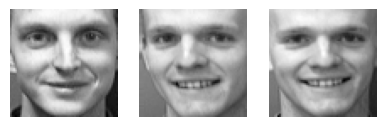

label = 80


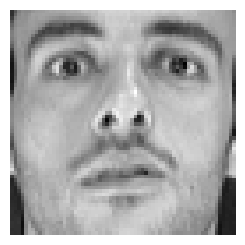

label = 81


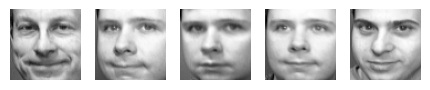

label = 82


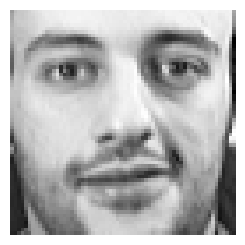

label = 83


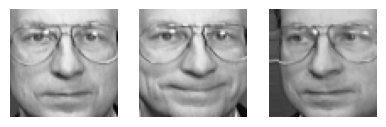

label = 84


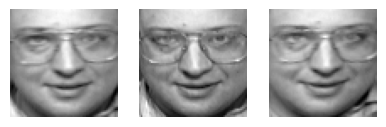

label = 85


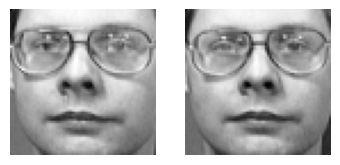

label = 86


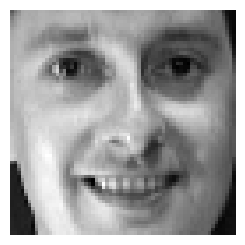

label = 87


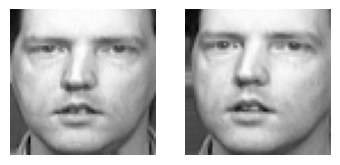

label = 88


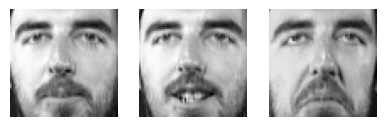

label = 89


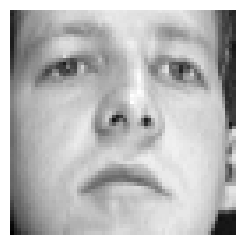

label = 90


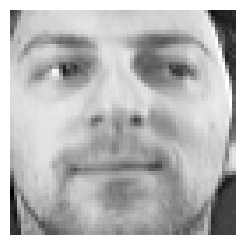

label = 91


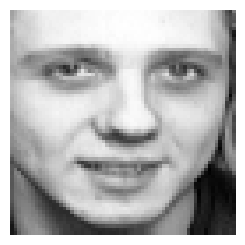

label = 92


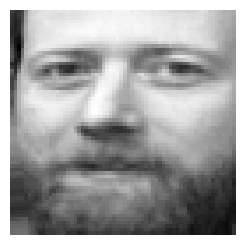

label = 93


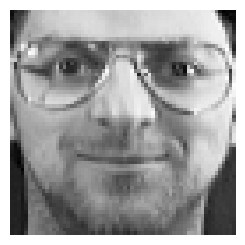

label = 94


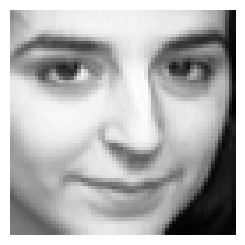

In [30]:
cluster = 95
from sklearn.cluster import KMeans
km = KMeans(n_clusters=cluster, random_state=42)
km.fit(X_train_pca)

for c_label in np.unique(km.labels_):
    print(f'label = {c_label}')
    row_count = X_train[km.labels_ == c_label].shape[0]

    show_images = X_train[km.labels_ == c_label]

    for idx in range(row_count):
        plt.subplot(1, row_count+1, idx+1)
        plt.imshow(show_images[idx].reshape(64, 64), cmap='gray')
        plt.axis('off')
    plt.show()

In [31]:
# 분류기
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
rfc.fit(X_train_pca, y_train)
rfc.score(X_test_pca, y_test)

0.90625

In [32]:
# 새로운 라벨링     k평균을 차원 축소 도구로 사용
X_train_reduced = km.transform(X_train_pca)
X_test_reduced = km.transform(X_test_pca)
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_reduced, y_train)
clf.score(X_test_reduced, y_test)

0.73125

In [33]:
#clf.fit, clf.score를 파이프라인으로 묶기
from sklearn.pipeline import Pipeline 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
pipeline = Pipeline([
    ('pca', PCA(n_components=0.99, random_state=42)),
    ('cluster', KMeans(random_state=42)),
    ('rfc', RandomForestClassifier(n_estimators=200, random_state=42))
])
k_range = range(5, 200, 5)
scores= []
for k in k_range:
    pipeline.set_params(cluster__n_clusters=k)
    pipeline.fit(X_train, y_train)
    scores.append(pipeline.score(X_test, y_test))

max_index = np.argmax(scores)
print(f'정확도 : {np.max(scores)} 클러스터개수 : {k_range[max_index]}')


c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a m

정확도 : 0.78125 클러스터개수 : 165


# [7교시]

In [34]:
# dbscan
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
pca = PCA(n_components=0.99, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
print(f'conponet : {pca.components_}')
dbscan = DBSCAN(eps=5, min_samples=5)
dbscan.fit(X_train)
dbscan.labels_

conponet : [[ 0.00194317  0.00435227  0.00507423 ...  0.00053164 -0.00282986
  -0.00307174]
 [ 0.02799511  0.03267452  0.03844768 ... -0.0306867  -0.02766022
  -0.02384278]
 [ 0.00182524 -0.00059501  0.00293012 ... -0.02283142 -0.02299649
  -0.01956934]
 ...
 [ 0.00610187 -0.01268816 -0.00373004 ... -0.03728436  0.00617533
   0.03431762]
 [ 0.00426072  0.01099173  0.02958088 ... -0.0409191  -0.03183912
  -0.03925789]
 [-0.02329256 -0.02697709 -0.01200272 ... -0.00503821 -0.01164675
  -0.01001945]]


array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1

In [35]:
from sklearn.cluster import AgglomerativeClustering
model_average = AgglomerativeClustering


In [36]:
n_clusters = 100
from sklearn.cluster import AgglomerativeClustering
model_single = AgglomerativeClustering(n_clusters=n_clusters, linkage='single')
model_complete = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')
model_average = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')

model_average.fit_predict(X_train_pca)

array([18, 43,  4, 18, 28,  2, 90, 21, 18, 32, 32,  2, 85, 38, 28, 96, 25,
       55, 81, 11,  4, 19, 94,  8, 63, 13, 16, 30, 25,  3, 19,  2, 91, 89,
       82, 34, 27, 87, 24, 17, 75, 21, 82,  8,  1, 92,  8,  1, 12, 51, 64,
       19, 69,  4,  4, 73, 88, 12, 79, 27, 40, 86,  9, 33, 98, 11, 20, 23,
       54, 76, 57, 37, 90, 40,  7, 41, 82, 75, 76, 25, 30,  0, 33, 58, 21,
       29, 70, 31, 24,  2, 40, 60, 74,  8,  2, 59, 88, 11,  5, 83, 11, 56,
       22, 14,  1, 68,  4, 48, 45, 52,  4, 21, 25, 26, 53, 33, 95,  0, 93,
       67,  2, 46, 30, 10, 48, 12, 41, 23, 25, 24, 99, 10, 97,  7, 28, 12,
       49, 17,  0, 35, 58, 38, 36, 57, 95, 12, 28, 61, 28, 17,  0,  9, 44,
       65, 43, 14,  2, 78,  5, 49,  4,  2, 84, 98,  0,  9,  9, 68, 42,  6,
       15, 52, 15, 75, 30, 48, 22, 29, 62, 35,  0, 81, 19, 77, 13,  0, 56,
       18, 12, 34,  2, 26,  1, 39, 50, 59, 41, 72, 41, 21, 13, 25,  2, 62,
       40,  8, 12, 28,  5, 80,  1,  8, 20, 41, 14, 24, 39, 24, 16, 47, 52,
       47, 12,  6, 98, 12

In [37]:
#clf.fit, clf.score를 파이프라인으로 묶기
from sklearn.pipeline import Pipeline 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pca = PCA(n_components=0.99, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
model_average = AgglomerativeClustering(n_clusters=100, linkage='average')
y_train_pca_cluster = model_average.fit_predict(X_train_pca)
X_train_pca_cluster = model_average.fit_predict(X_train_pca)
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
rfc.fit(X_train_pca, y_train_pca_cluster)

y_test_pca_cluster = rfc.predict(X_test_pca)
rfc.fit(X_train_pca, y_train_pca_cluster)
y_test_predict = rfc.predict(X_test_pca)
rfc.score(X_test_pca, y_test_predict)

# pipeline = Pipeline([
#     ('pca', PCA(n_components=0.99, random_state=42)),
#     ('cluster', AgglomerativeClustering),
#     ('model', RandomForestClassifier(n_estimators=200, random_state=42))
# ])
# k_range = range(5, 200, 5)
# scores= []
# for k in k_range:
#     pipeline.set_params(cluster__n_clusters=k, cluster__linkage='average')
#     pipeline.fit(X_train, y_train)
#     scores.append(pipeline.score(X_test, y_test))

# max_index = np.argmax(scores)
# print(f'정확도 : {np.max(scores)} 클러스터개수 : {k_range[max_index]}')


1.0

In [38]:
#clf.fit, clf.score를 파이프라인으로 묶기
from sklearn.pipeline import Pipeline 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pca = PCA(n_components=0.99, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
model_average = AgglomerativeClustering(n_clusters=100, linkage='average')
y_train_pca_cluster = model_average.fit_predict(X_train_pca)
X_train_pca_cluster = model_average.fit_predict(X_train_pca)
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
rfc.fit(X_train_pca, y_train_pca_cluster)

y_test_pca_cluster = rfc.predict(X_test_pca)
rfc.fit(X_train_pca, y_train_pca_cluster)
y_test_predict = rfc.predict(X_test_pca)
rfc.score(X_test_pca, y_test_predict)

# pipeline = Pipeline([
#     ('pca', PCA(n_components=0.99, random_state=42)),
#     ('cluster', AgglomerativeClustering),
#     ('model', RandomForestClassifier(n_estimators=200, random_state=42))
# ])
# k_range = range(5, 200, 5)
# scores= []
# for k in k_range:
#     pipeline.set_params(cluster__n_clusters=k, cluster__linkage='average')
#     pipeline.fit(X_train, y_train)
#     scores.append(pipeline.score(X_test, y_test))

# max_index = np.argmax(scores)
# print(f'정확도 : {np.max(scores)} 클러스터개수 : {k_range[max_index]}')


1.0

# [8교시]